
# Paso 02 — Patrón origen-destino por franja horaria (Tarea 3)

Construye la intensidad de demanda para cada par ordenado de nodos y cada franja
horaria, adaptando el método multiplicativo de **Braathen, Goez & Guajardo (2024),
§4.1** ("Generating passenger groups and routes").

**Préstamo metodológico vs. aporte propio — para que quede explícito:**

| Elemento | Origen |
|---|---|
| Fórmula multiplicativa `pop = f(p1 * p2 * p3 * p4)` | Braathen et al. §4.1 |
| Los 4 factores son: día, hora, y **un solo puntaje de estación** (igual de origen que de destino) | Braathen et al. §4.1 |
| Puntajes de estación puestos "a criterio" (sin tabla publicada) | Braathen et al. — **no reproducible**, por eso no los copiamos |
| Sustituir los puntajes de estación por masas reales SSB (Tareas 0-2) | **Aporte propio de esta tesis** |
| Separar el puntaje por rol: población si es origen, empleo si es destino (con inversión AM/PM) | **Aporte propio** |
| Factor de distancia decreciente con el tiempo de viaje navegable | **Aporte propio** (el paper no pondera así en §4.1) |
| Factores de franja horaria y día de semana | Con criterio propio (igual que el paper), configurables en `config/instance.yaml` |


In [1]:

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import masas
import patron_od

BASE_DIR = Path.cwd().parent
CONFIG_PATH = BASE_DIR / "config" / "instance.yaml"
OUTPUT_DIR = BASE_DIR / "output"

cfg = masas.cargar_config(CONFIG_PATH)
resumen_masas = pd.read_csv(OUTPUT_DIR / "masas_por_nodo.csv", index_col="id")
matriz_tiempos = patron_od.cargar_matriz_tiempos(cfg, BASE_DIR)

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

print("Matriz de tiempos navegables (min), de bergen-boats/02_ruteo_navegable:")
matriz_tiempos.round(1)


Matriz de tiempos navegables (min), de bergen-boats/02_ruteo_navegable:


,kleppesto,laksevag,bryggen,sandviken
kleppesto,0.0,5.3,11.5,9.6
laksevag,5.3,0.0,8.6,8.6
bryggen,11.5,8.6,0.0,6.8
sandviken,9.6,8.6,6.8,0.0


## Normalización de masas

Población y empleo tienen escalas muy distintas (cientos vs. miles) — antes de
multiplicarlas hay que llevarlas a una escala comparable. Se normaliza cada una
dividiendo por el máximo entre los 4 nodos (queda en `(0, 1]`, con el nodo más
grande en `1.0`). El `factor_universitario` (placeholder, todo en 1.0 por ahora)
se aplica sobre el empleo normalizado.


In [2]:

masas_norm = patron_od.normalizar_masas(resumen_masas, cfg)
masas_norm[["poblacion_total", "poblacion_norm", "empleo_total", "empleo_norm", "factor_universitario", "empleo_norm_ajustado", "mixta_norm"]]


,poblacion_total,poblacion_norm,empleo_total,empleo_norm,factor_universitario,empleo_norm_ajustado,mixta_norm
id,,,,,,,
kleppesto,25153,0.908214,7550,0.144600,0.70,0.101220,0.504717
laksevag,15986,0.577216,7760,0.148622,0.85,0.126329,0.351772
bryggen,27695,1.000000,52213,1.000000,1.00,1.000000,1.000000
sandviken,11109,0.401119,4106,0.078639,1.00,0.078639,0.239879


## Intensidad O-D por franja

Para cada franja horaria y cada par ordenado origen→destino (12 pares por franja:
4 nodos × 3 destinos posibles cada uno), se calcula:

```
intensidad = peso_origen(rol_franja) * peso_destino(rol_franja) * factor_distancia * factor_volumen_franja
factor_distancia = exp(-tiempo_viaje_min / tau_min)
```


In [3]:

intensidad_od = patron_od.construir_intensidad_od(cfg, masas_norm, matriz_tiempos)
intensidad_od.to_csv(OUTPUT_DIR / "matriz_intensidad_od.csv", index=False)
print(f"{len(intensidad_od)} filas (4 franjas x 12 pares) guardadas en output/matriz_intensidad_od.csv")
intensidad_od.head(50)


48 filas (4 franjas x 12 pares) guardadas en output/matriz_intensidad_od.csv


,franja,hora_inicio,hora_fin,origen,destino,rol_origen,rol_destino,peso_origen,peso_destino,tiempo_viaje_min,factor_distancia,factor_volumen_franja,intensidad
0,manana,6,9,kleppesto,laksevag,poblacion,empleo,0.908214,0.126329,5.331900,0.700851,1.00,0.080411
1,manana,6,9,kleppesto,bryggen,poblacion,empleo,0.908214,1.000000,11.502195,0.464491,1.00,0.421857
2,manana,6,9,kleppesto,sandviken,poblacion,empleo,0.908214,0.078639,9.562427,0.528615,1.00,0.037754
3,manana,6,9,laksevag,kleppesto,poblacion,empleo,0.577216,0.101220,5.331900,0.700851,1.00,0.040948
4,manana,6,9,laksevag,bryggen,poblacion,empleo,0.577216,1.000000,8.611502,0.563211,1.00,0.325095
5,manana,6,9,laksevag,sandviken,poblacion,empleo,0.577216,0.078639,8.610587,0.563246,1.00,0.025567
6,manana,6,9,bryggen,kleppesto,poblacion,empleo,1.000000,0.101220,11.502195,0.464491,1.00,0.047016
7,manana,6,9,bryggen,laksevag,poblacion,empleo,1.000000,0.126329,8.611502,0.563211,1.00,0.071150
8,manana,6,9,bryggen,sandviken,poblacion,empleo,1.000000,0.078639,6.828872,0.634284,1.00,0.049880
9,manana,6,9,sandviken,kleppesto,poblacion,empleo,0.401119,0.101220,9.562427,0.528615,1.00,0.021462


### Matrices O-D por franja (pivotadas, más fáciles de leer)


In [4]:

for franja_id in [f["id"] for f in cfg["franjas_horarias"]]:
    sub = intensidad_od[intensidad_od["franja"] == franja_id]
    piv = sub.pivot(index="origen", columns="destino", values="intensidad")
    print(f"--- {franja_id} ---")
    display(piv.round(4))


--- manana ---


destino,bryggen,kleppesto,laksevag,sandviken
origen,,,,
bryggen,NaN,0.0470,0.0711,0.0499
kleppesto,0.4219,NaN,0.0804,0.0378
laksevag,0.3251,0.0409,NaN,0.0256
sandviken,0.2544,0.0215,0.0285,NaN


--- valle ---


destino,bryggen,kleppesto,laksevag,sandviken
origen,,,,
bryggen,NaN,0.0938,0.0792,0.0609
kleppesto,0.0938,NaN,0.0498,0.0256
laksevag,0.0792,0.0498,NaN,0.0190
sandviken,0.0609,0.0256,0.0190,NaN


--- tarde ---


destino,bryggen,kleppesto,laksevag,sandviken
origen,,,,
bryggen,NaN,0.4219,0.3251,0.2544
kleppesto,0.0470,NaN,0.0409,0.0215
laksevag,0.0711,0.0804,NaN,0.0285
sandviken,0.0499,0.0378,0.0256,NaN


--- noche ---


destino,bryggen,kleppesto,laksevag,sandviken
origen,,,,
bryggen,NaN,0.0352,0.0297,0.0228
kleppesto,0.0352,NaN,0.0187,0.0096
laksevag,0.0297,0.0187,NaN,0.0071
sandviken,0.0228,0.0096,0.0071,NaN


### Heatmaps O-D por franja


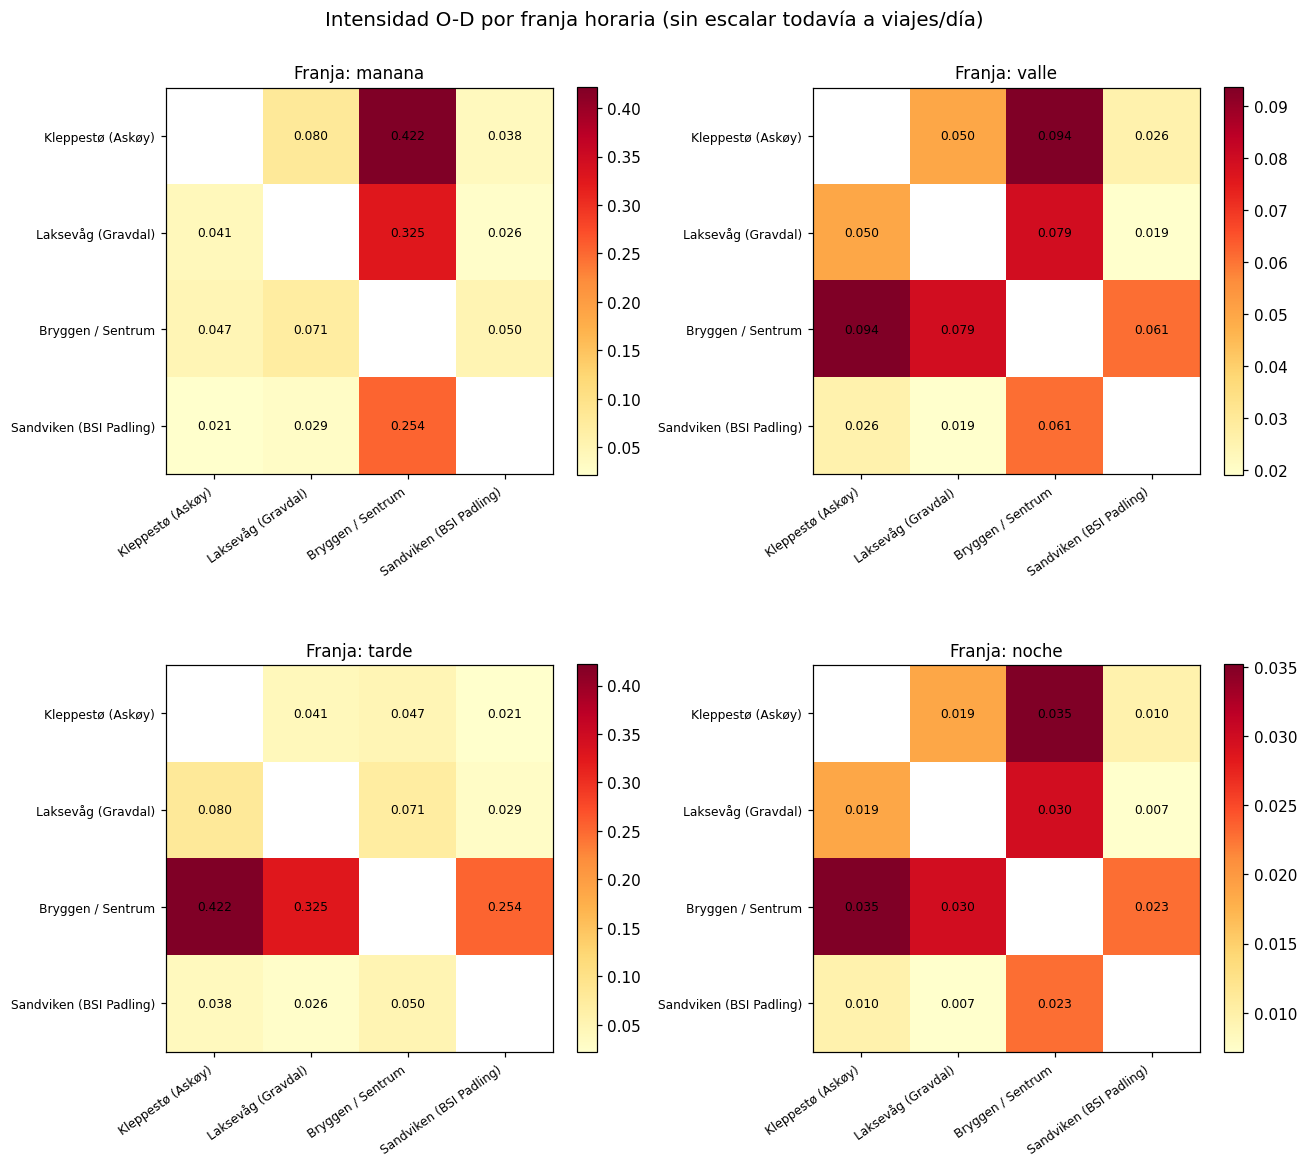

In [5]:

franja_ids = [f["id"] for f in cfg["franjas_horarias"]]
fig, axes = plt.subplots(2, 2, figsize=(12, 11))

ids_nodos = masas_norm.index.tolist()
nombres_nodos = masas_norm["nombre"].tolist()

for ax, franja_id in zip(axes.flat, franja_ids):
    sub = intensidad_od[intensidad_od["franja"] == franja_id]
    piv = sub.pivot(index="origen", columns="destino", values="intensidad").reindex(index=ids_nodos, columns=ids_nodos)
    im = ax.imshow(piv.values, cmap="YlOrRd")
    ax.set_xticks(range(len(ids_nodos))); ax.set_xticklabels(nombres_nodos, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(ids_nodos))); ax.set_yticklabels(nombres_nodos, fontsize=8)
    for i in range(len(ids_nodos)):
        for j in range(len(ids_nodos)):
            v = piv.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"Franja: {franja_id}", fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle("Intensidad O-D por franja horaria (sin escalar todavía a viajes/día)", fontsize=13)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heatmaps_od_por_franja.png", dpi=180, bbox_inches="tight")
plt.show()


## Verificación: ¿aparece la inversión de dirección mañana/tarde?

En vez de fijar a mano un "90/10 hacia Bryggen en la mañana" (como se había supuesto
sin datos en `docs/parametros_instancia_base_bergen.md`), dejamos que la dirección
dominante **emerja** del modelo: población alta en los barrios + empleo alto en
Bryggen ya deberían generar la asimetría por sí solas. Aquí se mide qué proporción
salió realmente, y se compara contra ese supuesto original.


In [6]:

filas = [patron_od.resumen_direccion_bryggen(intensidad_od, f["id"]) for f in cfg["franjas_horarias"]]
direccion_df = pd.DataFrame(filas)
direccion_df


,franja,intensidad_hacia_hub,intensidad_desde_hub,pct_hacia_hub,pct_desde_hub
0,manana,1.001376,0.168045,85.6,14.4
1,valle,0.233884,0.233884,50.0,50.0
2,tarde,0.168045,1.001376,14.4,85.6
3,noche,0.087707,0.087707,50.0,50.0


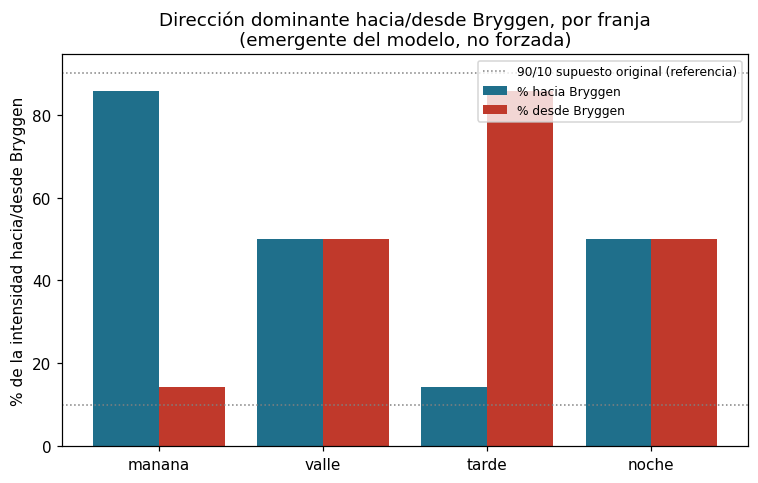

In [7]:

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(direccion_df))
ax.bar(x - 0.2, direccion_df["pct_hacia_hub"], width=0.4, label="% hacia Bryggen", color="#1f6f8b")
ax.bar(x + 0.2, direccion_df["pct_desde_hub"], width=0.4, label="% desde Bryggen", color="#c0392b")
ax.axhline(90, color="gray", linestyle=":", linewidth=1, label="90/10 supuesto original (referencia)")
ax.axhline(10, color="gray", linestyle=":", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(direccion_df["franja"])
ax.set_ylabel("% de la intensidad hacia/desde Bryggen")
ax.set_title("Dirección dominante hacia/desde Bryggen, por franja\n(emergente del modelo, no forzada)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "inversion_direccion_bryggen.png", dpi=180, bbox_inches="tight")
plt.show()


## Factor de distancia

Forma del decaimiento `exp(-tiempo_min / tau_min)` con el `tau_min` configurado,
sobre el rango real de tiempos de viaje de la instancia.


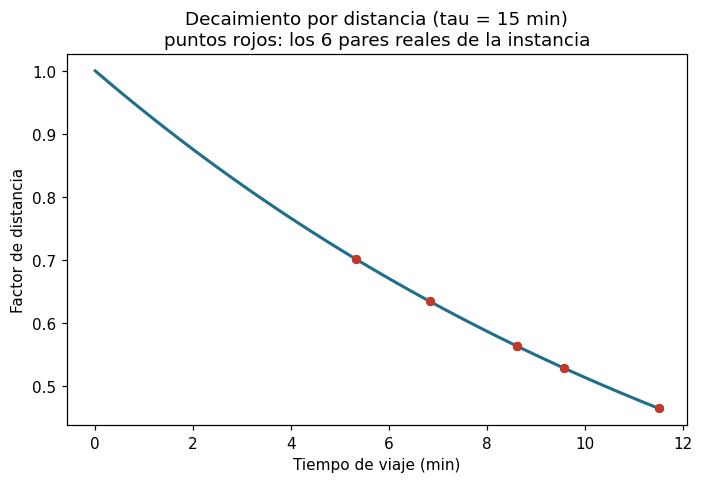

In [8]:

tau_min = cfg["factor_distancia"]["tau_min"]
tiempos_grid = np.linspace(0, matriz_tiempos.values[matriz_tiempos.values > 0].max(), 100)
factor = np.exp(-tiempos_grid / tau_min)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(tiempos_grid, factor, color="#1f6f8b", linewidth=2)
for _, row in intensidad_od.drop_duplicates(["origen", "destino"]).iterrows():
    ax.scatter([row["tiempo_viaje_min"]], [np.exp(-row["tiempo_viaje_min"] / tau_min)], color="#c0392b", zorder=3, s=25)
ax.set_xlabel("Tiempo de viaje (min)")
ax.set_ylabel("Factor de distancia")
ax.set_title(f"Decaimiento por distancia (tau = {tau_min} min)\npuntos rojos: los 6 pares reales de la instancia")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_distancia.png", dpi=180, bbox_inches="tight")
plt.show()



## Resumen

- `output/matriz_intensidad_od.csv`: intensidad O-D completa, 4 franjas × 12 pares.
- `output/heatmaps_od_por_franja.png`: matrices O-D visuales por franja.
- `output/inversion_direccion_bryggen.png`: verificación de la dirección dominante (emergente, no forzada).
- `output/factor_distancia.png`: forma del decaimiento por distancia.
- **Siguiente paso:** `03_llegadas.ipynb` — Tarea 4, generar llegadas minuto a minuto (día y semana).
